# Archetypes

🧐 **What kinds of Taskmaster contestants tend to exist?**

🎯 Goal: Group contestants into interpretable performance archetypes using historical episode-level features

Approach:

1. Convert DF to one row per contestant
2. Choose and scale a small set of summary features
3. Run KMeans
4. Inspect and name the clusters

### Executive Summary

Using historical Taskmaster data, contestants were grouped into five performance archetypes based on scoring, consistency, and momentum.

These archetypes show clear separation in performance, with Elite but Chaotic and Strong & Consistent emerging as the strongest groups.

Crucially, all winners come from just these two archetypes, while other groups rarely or never win.

This suggests that Taskmaster rewards high absolute performance - either through sustained excellence or standout peak performance - rather than improvement or consistency alone.

| Archetype (Original)  | TaskLab Name        | Description                      | Example Contestants |
| --------------------- | ------------------- | -------------------------------- | ------------------- |
| Elite but Chaotic  | 🔥 The Chaos Engine    | High scoring, high variance      | Katherine Ryan, Dara Ó Briain, Liza Tarbuck |
| Strong & Consistent | 🎯 The Silent Assassin | High scoring, reliable           | Noel Fielding, Kerry Godliman, Sarah Millican |
| Chaotic Improvers  | 🌸 The Late Bloomer    | Improving, but inconsistent      | Mel Giedroyc, Asim Chaudhry, Kiell Smith-Bynoe |
| Solid but Fading   | 🏁 The Early Leader    | Strong start, declining          | Chris Ramsey, Rhod Gilbert, Guz Khan |
| Strugglers         | 🍍 The Underdog        | Low scoring, limited improvement | Julian Clary, Tim Key, Sara Pascoe |




### Imports and constants

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

RAW_PATH = DATA_DIR / "raw"
PROCESSED_PATH = DATA_DIR / "processed"

### Load the data

In [2]:
task_df = pd.read_csv(PROCESSED_PATH / "task_clean_df.csv")

task_df.shape

(730, 12)

In [3]:
task_df.columns.tolist()

['episode',
 'episode_label',
 'contestant',
 'episode_score',
 'series_id',
 'episode_in_series',
 'cumulative_score',
 'mean_score_so_far',
 'std_score_so_far',
 'recent_avg_score',
 'momentum',
 'episodes_played']

In [4]:
task_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   episode            730 non-null    int64  
 1   episode_label      730 non-null    object 
 2   contestant         730 non-null    object 
 3   episode_score      730 non-null    int64  
 4   series_id          730 non-null    int64  
 5   episode_in_series  730 non-null    int64  
 6   cumulative_score   730 non-null    int64  
 7   mean_score_so_far  730 non-null    float64
 8   std_score_so_far   730 non-null    float64
 9   recent_avg_score   730 non-null    float64
 10  momentum           730 non-null    float64
 11  episodes_played    730 non-null    int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 68.6+ KB


## Creating Archetype clusters

### Build the archetype dataframe

In [5]:
archetype_df = (
    task_df.groupby(["series_id", "contestant"])
    .agg(
        avg_score=("episode_score", "mean"), # how strong
        avg_cumulative_score=("cumulative_score", "mean"),
        avg_std=("std_score_so_far", "mean"), # how chaotic
        avg_momentum=("momentum", "mean"), # trends
        best_episode_score=("episode_score", "max"), # ceiling
        worst_episode_score=("episode_score", "min"), # floor
        episodes_played=("episode", "count")
    )
    .reset_index()
)

archetype_df.head()

,series_id,contestant,avg_score,avg_cumulative_score,avg_std,avg_momentum,best_episode_score,worst_episode_score,episodes_played
0,1,Frank Skinner,15.500000,52.833333,4.091243,0.336111,20,9,6
1,1,Josh Widdicombe,15.666667,56.500000,3.034590,0.347222,22,9,6
2,1,Roisin Conaty,11.333333,41.000000,5.807999,-0.111111,21,7,6
3,1,Romesh Ranganathan,15.500000,57.666667,3.659558,-0.880556,22,10,6
4,1,Tim Key,14.666667,53.500000,2.342562,-1.277778,18,9,6


In [6]:
# Filter out 1 episode contestants (New Year Treat, Champion of Champions)
archetype_df = archetype_df[archetype_df["episodes_played"] > 3]

### Cluster features

In [7]:
feature_cols = [
    "avg_score",
    "avg_std",
    "avg_momentum",
    "best_episode_score",
    "worst_episode_score"
]

X = archetype_df[feature_cols]
X.head()

,avg_score,avg_std,avg_momentum,best_episode_score,worst_episode_score
0,15.500000,4.091243,0.336111,20,9
1,15.666667,3.034590,0.347222,22,9
2,11.333333,5.807999,-0.111111,21,7
3,15.500000,3.659558,-0.880556,22,10
4,14.666667,2.342562,-1.277778,18,9


In [8]:
# Scale features since KNN cares about distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Clusters v1

In [9]:
# Start with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

archetype_df["cluster"] = kmeans.fit_predict(X_scaled)

# Inspect clusters
cluster_summary = (
    archetype_df.groupby("cluster")[feature_cols]
    .mean()
    .round(2)
)

cluster_summary

,avg_score,avg_std,avg_momentum,best_episode_score,worst_episode_score
cluster,,,,,
0,14.39,4.23,0.52,21.85,7.35
1,16.54,2.25,0.07,20.83,12.50
2,16.70,3.87,-0.35,24.46,9.85
3,13.75,2.40,-0.71,18.40,8.90


In [10]:
# ----- Optimise the number of clusters -----
# Which number gives the most meaningful groupings?

# Greater silhouette score = better separation between clusters
for k in [3, 4, 5, 6, 7, 8, 9, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette_score={score:.5f}")

k=3, silhouette_score=0.24493
k=4, silhouette_score=0.24920
k=5, silhouette_score=0.23374
k=6, silhouette_score=0.24860
k=7, silhouette_score=0.26747
k=8, silhouette_score=0.27669
k=9, silhouette_score=0.23759
k=10, silhouette_score=0.22562


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: Runtim

In [11]:
# Inspect results
for k in [4, 5, 6, 8]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    archetype_df[f"cluster_{k}"] = kmeans.fit_predict(X_scaled)

    print(f"\n--- k={k} ---")
    print(
        archetype_df.groupby(f"cluster_{k}")[feature_cols]
        .mean()
        .round(2)
    )


--- k=4 ---
           avg_score  avg_std  avg_momentum  best_episode_score  \
cluster_4                                                         
0              14.39     4.23          0.52               21.85   
1              16.54     2.25          0.07               20.83   
2              16.70     3.87         -0.35               24.46   
3              13.75     2.40         -0.71               18.40   

           worst_episode_score  
cluster_4                       
0                         7.35  
1                        12.50  
2                         9.85  
3                         8.90  

--- k=5 ---
           avg_score  avg_std  avg_momentum  best_episode_score  \
cluster_5                                                         
0              15.79     3.66         -0.32               22.39   
1              17.52     4.12         -0.16               26.50   
2              14.20     4.40          0.65               21.90   
3              16.50     2.29         

#### 🙋‍♀️ Choosing number of clusters

Silhouette score was used to guide k, which measures how well-separated clusters are.

Scores are relatively low (~0.24–0.28) and increase with higher k, peaking at k=8. This is expected because contestant behaviour is continuous, not naturally split into distinct groups, so clusters overlap rather than forming clean boundaries.

Rather than picking the highest score, k=4, 5, 6, 8  were inspected to enable selection based on interpretability and usefulness, not just the metric. The goal was to create a small number of **clear, explainable archetypes** - avoiding complex fragmentation.

🏆 **k=5**

 k=5 has the best balance of:

- capturing meaningful differences in performance (e.g. elite vs consistent)
- keeping clusters interpretable and usable

#### Archetype summary

| Archetype             | Description                                                    |
| --------------------- | -------------------------------------------------------------- |
| 🔥 Elite but Chaotic  | Very high scoring but inconsistent - big wins and big swings   |
| ⭐ Strong & Consistent | High scoring and reliable - steady performers                  |
| 🎢 Chaotic Improvers  | Volatile but trending upwards - finding form over time         |
| 📉 Solid but Fading   | Decent performers whose results decline over time              |
| 😬 Strugglers         | Lower scoring and not improving - consistently underperforming |


In [12]:
# Add placeholder archetype names
cluster_name_map = {
    0: "Solid but Fading",
    1: "Elite but Chaotic",
    2: "Chaotic Improvers",
    3: "Strong & Consistent",
    4: "Strugglers"
}

archetype_df["archetype"] = archetype_df["cluster_5"].map(cluster_name_map)

## Inspect the archetypes

### Archetype performance

In [13]:
# What's the size of each archetype?
archetype_df["archetype"].value_counts()

archetype
Chaotic Improvers      21
Strong & Consistent    19
Solid but Fading       18
Elite but Chaotic      12
Strugglers             10
Name: count, dtype: int64

In [14]:
# What do the archetype distributions look like?
archetype_df.groupby("archetype")[[
    "avg_score",
    "avg_std",
    "avg_momentum"
]].mean().round(2)

,avg_score,avg_std,avg_momentum
archetype,,,
Chaotic Improvers,14.20,4.40,0.65
Elite but Chaotic,17.52,4.12,-0.16
Solid but Fading,15.79,3.66,-0.32
Strong & Consistent,16.50,2.29,-0.01
Strugglers,13.75,2.40,-0.71


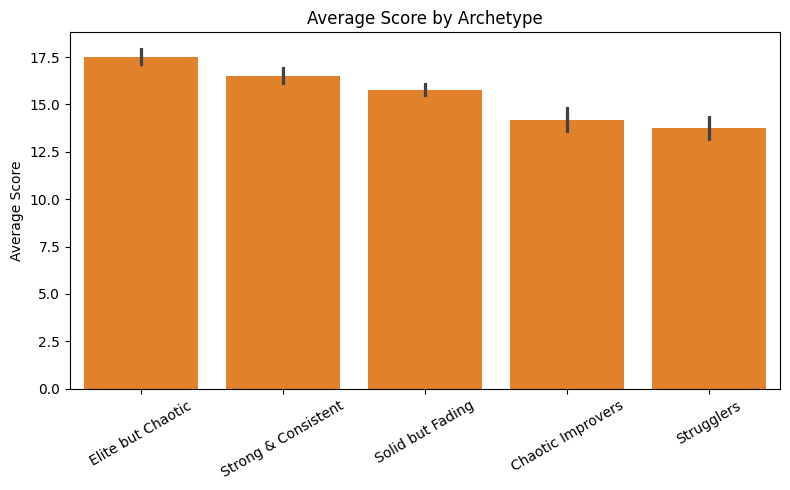

In [28]:
# Which archetypes perform best?

plt.figure(figsize=(8,5))

# Order by average score
order = (
    archetype_df.groupby("archetype")["avg_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    order=order
)

sns.barplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    estimator="mean"
)

plt.xticks(rotation=30)
plt.title("Average Score by Archetype")
plt.ylabel("Average Score")
plt.xlabel("")

plt.tight_layout()

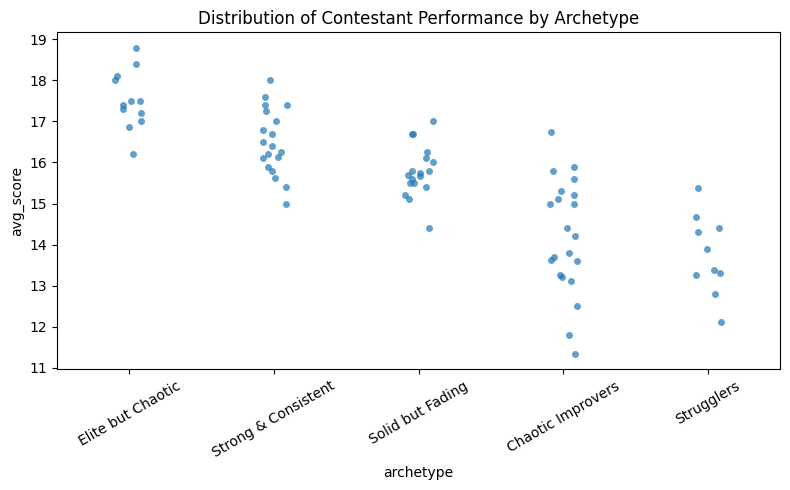

In [32]:
plt.figure(figsize=(8,5))

sns.stripplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    order=order,
    jitter=True,
    alpha=0.7
)

plt.xticks(rotation=30)
plt.title("Distribution of Contestant Performance by Archetype")
plt.tight_layout()

plt.show()

#### Archetype outcomes

Comparing winners vs non-winners by archetype

In [16]:
# Create a series winner table
winners_df = (
    task_df.sort_values(["series_id", "episode"])
    .groupby(["series_id", "contestant"])
    .tail(1)  # last episode per contestant
)

# Rank within each series
winners_df["final_rank"] = winners_df.groupby("series_id")["cumulative_score"] \
    .rank(ascending=False, method="first")

# Mark winner
winners_df["is_winner"] = winners_df["final_rank"] == 1

# Join with archetypes
analysis_df = winners_df.merge(
    archetype_df[["series_id", "contestant", "archetype"]],
    on=["series_id", "contestant"],
    how="left"
)

# Aggregate - count winners by archetype
winner_counts = (
    analysis_df[analysis_df["is_winner"]]
    .groupby("archetype")
    .size()
    .sort_values(ascending=False)
)

winner_counts

archetype
Strong & Consistent    8
Elite but Chaotic      7
Solid but Fading       1
dtype: int64

In [17]:
# Compare proportions

archetype_summary = (
    analysis_df.groupby("archetype")
    .agg(
        total=("contestant", "count"),
        winners=("is_winner", "sum")
    )
)

archetype_summary["win_rate"] = (
    archetype_summary["winners"] / archetype_summary["total"]
)

archetype_summary.sort_values("win_rate", ascending=False)

,total,winners,win_rate
archetype,,,
Elite but Chaotic,12,7,0.583333
Strong & Consistent,19,8,0.421053
Solid but Fading,18,1,0.055556
Chaotic Improvers,21,0,0.000000
Strugglers,10,0,0.000000


#### 📊 Archetype performance analysis

The archetypes show a clear separation in performance:

- **Elite but Chaotic** and **Strong & Consistent** are the top-performing groups, with the highest average scores.
- Lower-performing archetypes — particularly **Chaotic Improvers** and **Strugglers** — lag significantly behind, despite variability or improvement over time.

This pattern is reinforced when looking at outcomes 👉 **Despite identifying five distinct archetypes, all winners come from just two groups.**

- **Elite but Chaotic** → highest win rate
- **Strong & Consistent** → second highest
- All other archetypes → rarely or never win

##### 🎯 Key insight

**Taskmaster rewards high absolute performance, not improvement or consistency alone.**

Contestants who improve over time or perform steadily at a moderate level do not typically win. Instead, success is driven by either:
- Sustained high performance (Strong & Consistent), or
- High peak performance, even if volatile (Elite but Chaotic)

##### 💡 Takeaway

Despite exploring multiple archetypes, only two consistently produce winners — suggesting that **Taskmaster rewards either sustained excellence or standout peak performance**.

## Extra: Dynamic archetypes

Are archetypes fixed identities, or do contestants evolve?

In [18]:
# Select time features that describe different state across episodes
time_features = [
    "mean_score_so_far",
    "std_score_so_far",
    "momentum"
]

# Create a clean task_df subset for dynamic clustering
dynamic_df = task_df[time_features].copy()

# Remove any infinities or missing values
dynamic_df = dynamic_df.replace([np.inf, -np.inf], np.nan).dropna()

# Remove the earliest rows where "state" is not very meaningful
# e.g. episode 1 where std_score_so_far is always 0, momentum is not very informative
dynamic_df = dynamic_df[task_df.loc[dynamic_df.index, "episodes_played"] > 1]

# Scale features
time_scaler = StandardScaler()
X_time_scaled = time_scaler.fit_transform(dynamic_df)

# Fit a NEW KMeans model for dynamic performance states
# Using 4 clusters here as robustness tweak to reduce over-fragmentation
time_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model and get one cluster label per row in dynamic_df
dynamic_labels = time_kmeans.fit_predict(X_time_scaled)

# Write the labels back to task_df
# Default new column to NaN and fill only with rows clustered
task_df["dynamic_cluster"] = np.nan
task_df.loc[dynamic_df.index, "dynamic_cluster"] = dynamic_labels

# Make the non-missing labels integers for easier reading
task_df["dynamic_cluster"] = task_df["dynamic_cluster"].astype("Int64")

# Inspect the cluster summaries
dynamic_summary = (
    task_df.dropna(subset=["dynamic_cluster"])
    .groupby("dynamic_cluster")[time_features]
    .mean()
    .round(2)
)

dynamic_summary

/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,mean_score_so_far,std_score_so_far,momentum
dynamic_cluster,,,
0,16.94,2.44,0.11
1,13.00,3.63,0.02
2,15.95,5.18,2.31
3,15.89,4.84,-2.55


👉 Episode-level clustering was explored to test whether contestants move through different performance states over time. 

The resulting clusters were interpretable, broadly separating stable high performers, weaker states, rising chaotic states, and falling chaotic states. However, sklearn produced persistent numerical warnings during fitting, so the results are being treating as an exploratory extension rather than a robust core component of the model.

## Naming the clusters

In [34]:
cluster_name_map = {
    0: "The Early Leader",
    1: "The Chaos Engine",
    2: "The Late Bloomer",
    3: "The Silent Assassin",
    4: "The Underdog"
}

archetype_df["archetype_name"] = archetype_df["cluster"].map(cluster_name_map)

In [38]:
# Finding example contestants
example_df = (
    archetype_df.sort_values("avg_score", ascending=False)
    .groupby("archetype")
    .head(3)
)

example_df[["archetype", "contestant"]]

,archetype,contestant
8,Elite but Chaotic,Katherine Ryan
85,Elite but Chaotic,Dara Ó Briain
32,Elite but Chaotic,Liza Tarbuck
19,Strong & Consistent,Noel Fielding
37,Strong & Consistent,Kerry Godliman
89,Strong & Consistent,Sarah Millican
77,Solid but Fading,Chris Ramsey
18,Chaotic Improvers,Mel Giedroyc
39,Solid but Fading,Rhod Gilbert
67,Solid but Fading,Guz Khan


## Exporting artefacts

In [37]:
archetype_df[[
    "series_id",
    "contestant",
    "cluster",
    "archetype"
]].to_csv("../data/processed/archetypes.csv", index=False)